In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
%matplotlib inline


In [4]:
df = pd.read_csv('height-weight.csv')

In [5]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [ ]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [10]:
## Correleation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


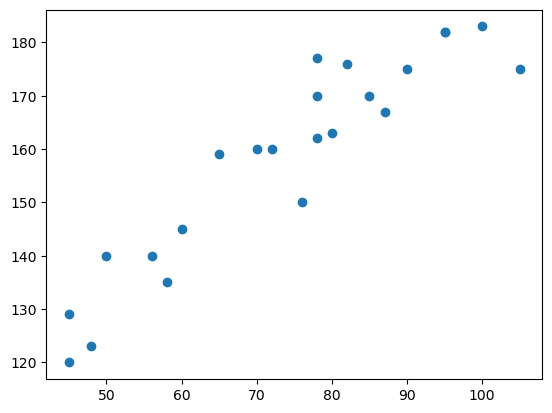

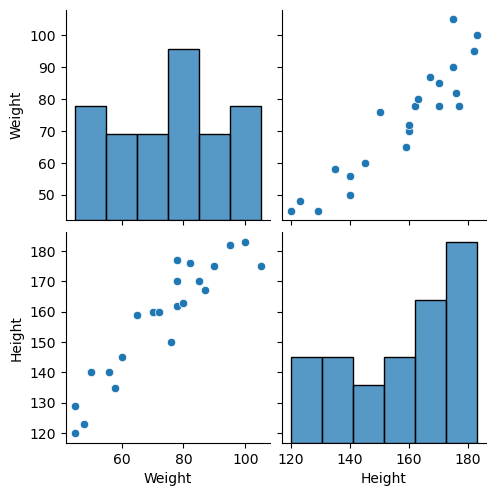

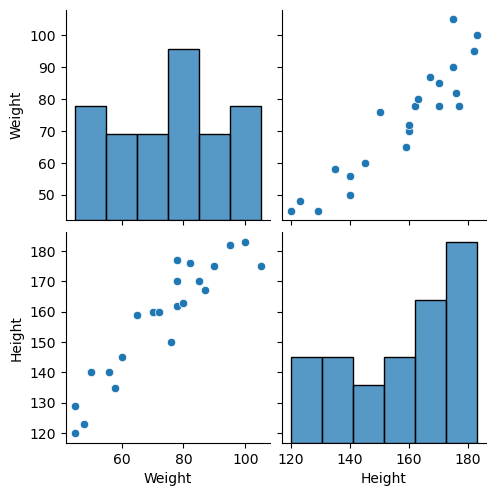

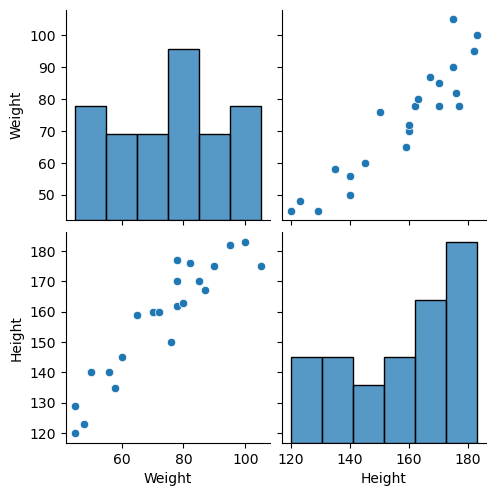

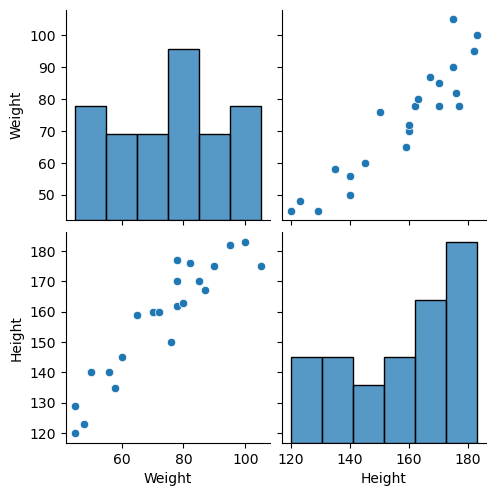

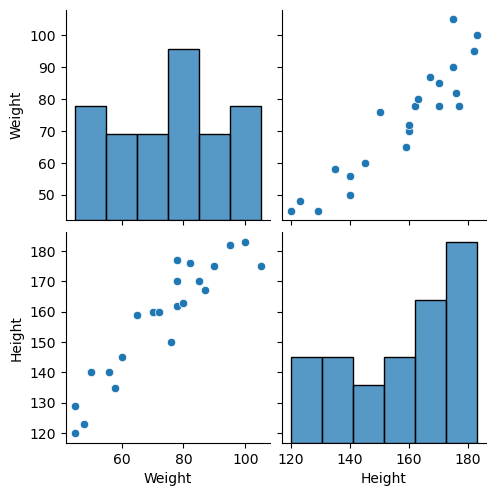

In [15]:
import seaborn as sns
sns.pairplot(df)
plt.show()

In [16]:
##Independent and Independent features
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [25]:
X = df[['Weight']] ##independent array or feature
y = df['Height']## Dependent feature

In [22]:
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [26]:
X_series = df['Weight']
np.array(y).shape

(23,)

In [27]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state = 42)

In [29]:
X_train.shape

(17, 1)

In [30]:
## Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)


In [31]:
## fit_transform used to transform only the train data with respect to Z score, 
# while we use transform only for test data as it should not be applied z score as it may cause data leakage
X_test = scaler.transform(X_test)


In [32]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [33]:
## Apply linear regression
from sklearn.linear_model import LinearRegression


In [36]:
regression = LinearRegression(n_jobs=-1)

In [37]:
regression.fit(X_train, y_train)

LinearRegression(n_jobs=-1)

In [40]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:", regression.intercept_)

Coefficient or slope: [17.2982057]
Intercept: 156.47058823529412


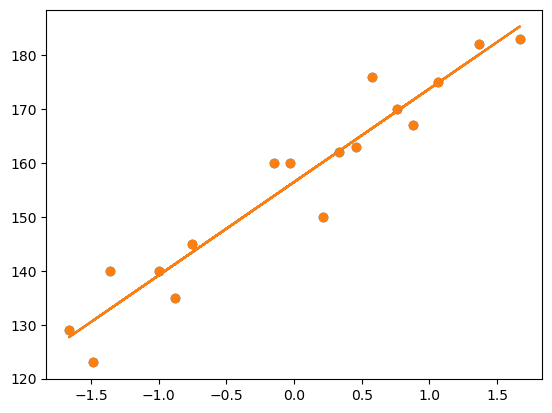

In [45]:
##plot training data best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train))
plt.show()

### Prediction
prediction height output = intercept +coef_(Weights)

y_pred_test = 156.470 + 1.26(X_test)

In [ ]:
##prediction for test data
y_pred = regression.predict(X_test)

In [48]:
### performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [49]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


In [51]:
from sklearn.metrics import r2_score

In [55]:
score = r2_score(y_test, y_pred)
print(score)

0.7360826717981276


In [53]:
## OLS Linear Regression
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [54]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 24 Jan 2026   Prob (F-statistic):                       0.664
Time:                        23:31:37   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [ ]:
## Prediction For new Data because it is not standardisex it shows large value
regression.predict([[72]])

array([1401.94139895])

In [57]:
## Standardize
regression.predict(scaler.transform([[72]]))

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])